# 🏋️ Phase 6 — Train YOLOv8s-seg

Train the finalized Phase 5 YOLO segmentation dataset on Google Colab GPU.

This notebook uses the exported dataset exactly as-is. It does not rebalance, rewrite labels, or modify `dataset_yolo/`.

## 1️⃣ Setup
Mount Drive, install dependencies, and define locked paths/config defaults.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q ultralytics pandas matplotlib seaborn scikit-learn pyyaml

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import json
import os
import shutil
import traceback
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from ultralytics import YOLO

warnings.filterwarnings('ignore')

DATA_YAML = Path('/content/drive/MyDrive/ai builders/dataset/dataset_yolo/data.yaml')
DRIVE_RUNS = Path('/content/drive/MyDrive/ai builders/runs')
RUN_NAME = 'solar_yolov8s_v1'
RUN_DIR = DRIVE_RUNS / RUN_NAME
FINAL_DIR = DRIVE_RUNS / f'{RUN_NAME}_final'

EXPECTED_NAMES = {
    0: 'panel_clean',
    1: 'panel_defective',
    2: 'dust',
    3: 'bird_drop',
    4: 'physical_damage',
    5: 'leaf',
}

# Set this to True only for a quick Colab smoke test. Full training keeps False.
SMOKE_TEST = False
SMOKE_EPOCHS = 1

DRIVE_RUNS.mkdir(parents=True, exist_ok=True)
FINAL_DIR.mkdir(parents=True, exist_ok=True)

print(f'✅ DATA_YAML: {DATA_YAML}')
print(f'✅ RUN_DIR:   {RUN_DIR}')
print(f'✅ FINAL_DIR: {FINAL_DIR}')
print(f'✅ SMOKE_TEST: {SMOKE_TEST}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ DATA_YAML: /content/drive/MyDrive/ai builders/dataset/dataset_yolo/data.yaml
✅ RUN_DIR:   /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1
✅ FINAL_DIR: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final
✅ SMOKE_TEST: False


## 2️⃣ GPU + Dataset Verification
Stop early if GPU is unavailable. Phase 6 full training is intended for Colab T4 or better.

In [3]:
def require_file(path, hint=''):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}\n{hint}')
    return path

def normalize_names(names):
    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}
    if isinstance(names, list):
        return {i: str(v) for i, v in enumerate(names)}
    raise ValueError(f'Unsupported names format: {type(names)}')

def count_split_files(dataset_root, split):
    img_dir = dataset_root / 'images' / split
    lbl_dir = dataset_root / 'labels' / split
    img_count = sum(1 for p in img_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'})
    lbl_count = sum(1 for p in lbl_dir.glob('*.txt'))
    return img_dir, lbl_dir, img_count, lbl_count

require_file(DATA_YAML, 'Run phase5_yolo_export.ipynb first.')

cuda_available = torch.cuda.is_available()
print(f'CUDA available: {cuda_available}')
if cuda_available:
    device_name = torch.cuda.get_device_name(0)
    total_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f'Device:         {device_name}')
    print(f'GPU memory:     {total_gb:.2f} GB')
else:
    raise RuntimeError('GPU is not available. Switch Colab Runtime > Change runtime type > T4 GPU, then rerun.')

with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

names = normalize_names(data_cfg.get('names'))
if int(data_cfg.get('nc', -1)) != 6 or names != EXPECTED_NAMES:
    raise ValueError(f'Unexpected data.yaml taxonomy. nc={data_cfg.get("nc")}, names={names}')

dataset_root = Path(data_cfg.get('path'))
if not dataset_root.exists():
    raise FileNotFoundError(f'Dataset root from data.yaml does not exist: {dataset_root}')

split_rows = []
for split in ['train', 'val', 'test']:
    img_dir, lbl_dir, img_count, lbl_count = count_split_files(dataset_root, split)
    if img_count == 0 or lbl_count == 0:
        raise ValueError(f'{split} split has zero images or labels: images={img_count}, labels={lbl_count}')
    split_rows.append({'split': split, 'image_dir': str(img_dir), 'label_dir': str(lbl_dir), 'images': img_count, 'labels': lbl_count})

split_df = pd.DataFrame(split_rows)
print('✅ Dataset verified')
print(f'Classes ({data_cfg["nc"]}): {names}')
display(split_df)

CUDA available: True
Device:         Tesla T4
GPU memory:     14.56 GB
✅ Dataset verified
Classes (6): {0: 'panel_clean', 1: 'panel_defective', 2: 'dust', 3: 'bird_drop', 4: 'physical_damage', 5: 'leaf'}


,split,image_dir,label_dir,images,labels
0,train,/content/drive/MyDrive/ai builders/dataset/dat...,/content/drive/MyDrive/ai builders/dataset/dat...,1863,1863
1,val,/content/drive/MyDrive/ai builders/dataset/dat...,/content/drive/MyDrive/ai builders/dataset/dat...,238,238
2,test,/content/drive/MyDrive/ai builders/dataset/dat...,/content/drive/MyDrive/ai builders/dataset/dat...,223,223


## 3️⃣ Training Config
Locked first-run config from `PHASE6_TRAINING_SPEC.md`. If batch 16 OOMs on a fresh run, the notebook retries once with batch 8.

In [4]:
run_name = f'{RUN_NAME}_smoke' if SMOKE_TEST else RUN_NAME
run_dir = DRIVE_RUNS / run_name
final_dir = DRIVE_RUNS / f'{run_name}_final'
final_dir.mkdir(parents=True, exist_ok=True)

train_config = {
    'data': str(DATA_YAML),
    'imgsz': 640,
    'batch': 16,
    'epochs': SMOKE_EPOCHS if SMOKE_TEST else 100,
    'patience': 20,
    'optimizer': 'auto',
    'lr0': 0.01,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3,
    'box': 7.5,
    'cls': 1.0,
    'dfl': 1.5,
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 10.0,
    'translate': 0.1,
    'scale': 0.5,
    'fliplr': 0.5,
    'flipud': 0.0,
    'mosaic': 1.0,
    'mixup': 0.1,
    'copy_paste': 0.3,
    'project': str(DRIVE_RUNS),
    'name': run_name,
    'exist_ok': True,
    'save': True,
    'save_period': 10,
    'device': 0,
    'workers': 8,
    'seed': 42,
    'verbose': True,
    'plots': True,
}

LAST_CKPT = run_dir / 'weights' / 'last.pt'
BEST_CKPT = run_dir / 'weights' / 'best.pt'

print('Training config:')
for k, v in train_config.items():
    print(f'  {k}: {v}')
print(f'\nRun dir: {run_dir}')
print(f'Resume checkpoint: {LAST_CKPT}')

Training config:
  data: /content/drive/MyDrive/ai builders/dataset/dataset_yolo/data.yaml
  imgsz: 640
  batch: 16
  epochs: 100
  patience: 20
  optimizer: auto
  lr0: 0.01
  lrf: 0.01
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 3
  box: 7.5
  cls: 1.0
  dfl: 1.5
  hsv_h: 0.015
  hsv_s: 0.7
  hsv_v: 0.4
  degrees: 10.0
  translate: 0.1
  scale: 0.5
  fliplr: 0.5
  flipud: 0.0
  mosaic: 1.0
  mixup: 0.1
  copy_paste: 0.3
  project: /content/drive/MyDrive/ai builders/runs
  name: solar_yolov8s_v1
  exist_ok: True
  save: True
  save_period: 10
  device: 0
  workers: 8
  seed: 42
  verbose: True
  plots: True

Run dir: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1
Resume checkpoint: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1/weights/last.pt


## 4️⃣ Train Or Resume
Resume automatically if `weights/last.pt` exists. For a fresh run, retry once with `batch=8` if CUDA OOM occurs.

In [5]:
def is_cuda_oom(error):
    text = str(error).lower()
    return 'out of memory' in text or ('cuda error' in text and 'memory' in text)

training_meta = {
    'started_at': datetime.now(timezone.utc).isoformat(),
    'run_name': run_name,
    'run_dir': str(run_dir),
    'resumed': False,
    'oom_retry_used': False,
    'effective_batch': train_config['batch'],
    'status': 'not_started',
    'error': None,
}

try:
    if LAST_CKPT.exists():
        print(f'🔄 Resuming from: {LAST_CKPT}')
        training_meta['resumed'] = True
        model = YOLO(str(LAST_CKPT))
        results = model.train(resume=True)
    else:
        print('🚀 Starting fresh training')
        model = YOLO('yolov8s-seg.pt')
        try:
            results = model.train(**train_config)
        except RuntimeError as e:
            if is_cuda_oom(e):
                print('⚠️ CUDA OOM at batch=16. Retrying once with batch=8.')
                torch.cuda.empty_cache()
                training_meta['oom_retry_used'] = True
                retry_config = dict(train_config)
                retry_config['batch'] = 8
                training_meta['effective_batch'] = 8
                model = YOLO('yolov8s-seg.pt')
                results = model.train(**retry_config)
                train_config = retry_config
            else:
                raise
    training_meta['status'] = 'completed'
    training_meta['completed_at'] = datetime.now(timezone.utc).isoformat()
    print('\n✅ Training complete')
    print(f'   Best weights: {BEST_CKPT}')
except Exception as e:
    training_meta['status'] = 'failed'
    training_meta['error'] = str(e)
    training_meta['traceback'] = traceback.format_exc()
    meta_path = final_dir / 'training_failure_meta.json'
    with open(meta_path, 'w', encoding='utf-8') as f:
        json.dump(training_meta, f, indent=2, ensure_ascii=False)
    print(f'❌ Training failed. Failure metadata saved: {meta_path}')
    raise

🚀 Starting fresh training
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ai builders/dataset/dataset_yolo/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=solar_yolov8s_v1, nbs=64, nms=False, o

## 5️⃣ Evaluate Best Model On Test Set
Run official test split evaluation and report box/mask metrics.

In [6]:
if not BEST_CKPT.exists():
    raise FileNotFoundError(f'Missing best checkpoint: {BEST_CKPT}')

best_model = YOLO(str(BEST_CKPT))
test_results = best_model.val(
    data=str(DATA_YAML),
    split='test',
    imgsz=640,
    batch=int(train_config.get('batch', 16)),
    save_json=True,
    save_txt=True,
    plots=True,
    verbose=True,
    project=str(DRIVE_RUNS),
    name=f'{run_name}_test_eval',
    exist_ok=True,
)

print('╔' + '═' * 58 + '╗')
print('║  Test Set Performance'.ljust(59) + '║')
print('╠' + '═' * 58 + '╣')
print(f'║  Box mAP@0.5:        {test_results.box.map50:.4f}'.ljust(59) + '║')
print(f'║  Box mAP@0.5:0.95:   {test_results.box.map:.4f}'.ljust(59) + '║')
print(f'║  Mask mAP@0.5:       {test_results.seg.map50:.4f}'.ljust(59) + '║')
print(f'║  Mask mAP@0.5:0.95:  {test_results.seg.map:.4f}'.ljust(59) + '║')
print('╚' + '═' * 58 + '╝')

class_names = names
print('Per-class segmentation AP from Ultralytics seg.maps:')
for i, name in class_names.items():
    value = float(test_results.seg.maps[i]) if i < len(test_results.seg.maps) else float('nan')
    print(f'  {name:<20} {value:.4f}')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,781,922 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.1±0.0 MB/s, size: 123.8 KB)
val: Scanning /content/drive/MyDrive/ai builders/dataset/dataset_yolo/labels/test... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 1.2it/s 3:04
val: New cache created: /content/drive/MyDrive/ai builders/dataset/dataset_yolo/labels/test.cache
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 319ms
Prepared 1 package in 48ms
Installed 1 package in 14ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P        

## 6️⃣ Confusion Matrix + Training Curves
Save review plots to the run folder and final artifact folder.

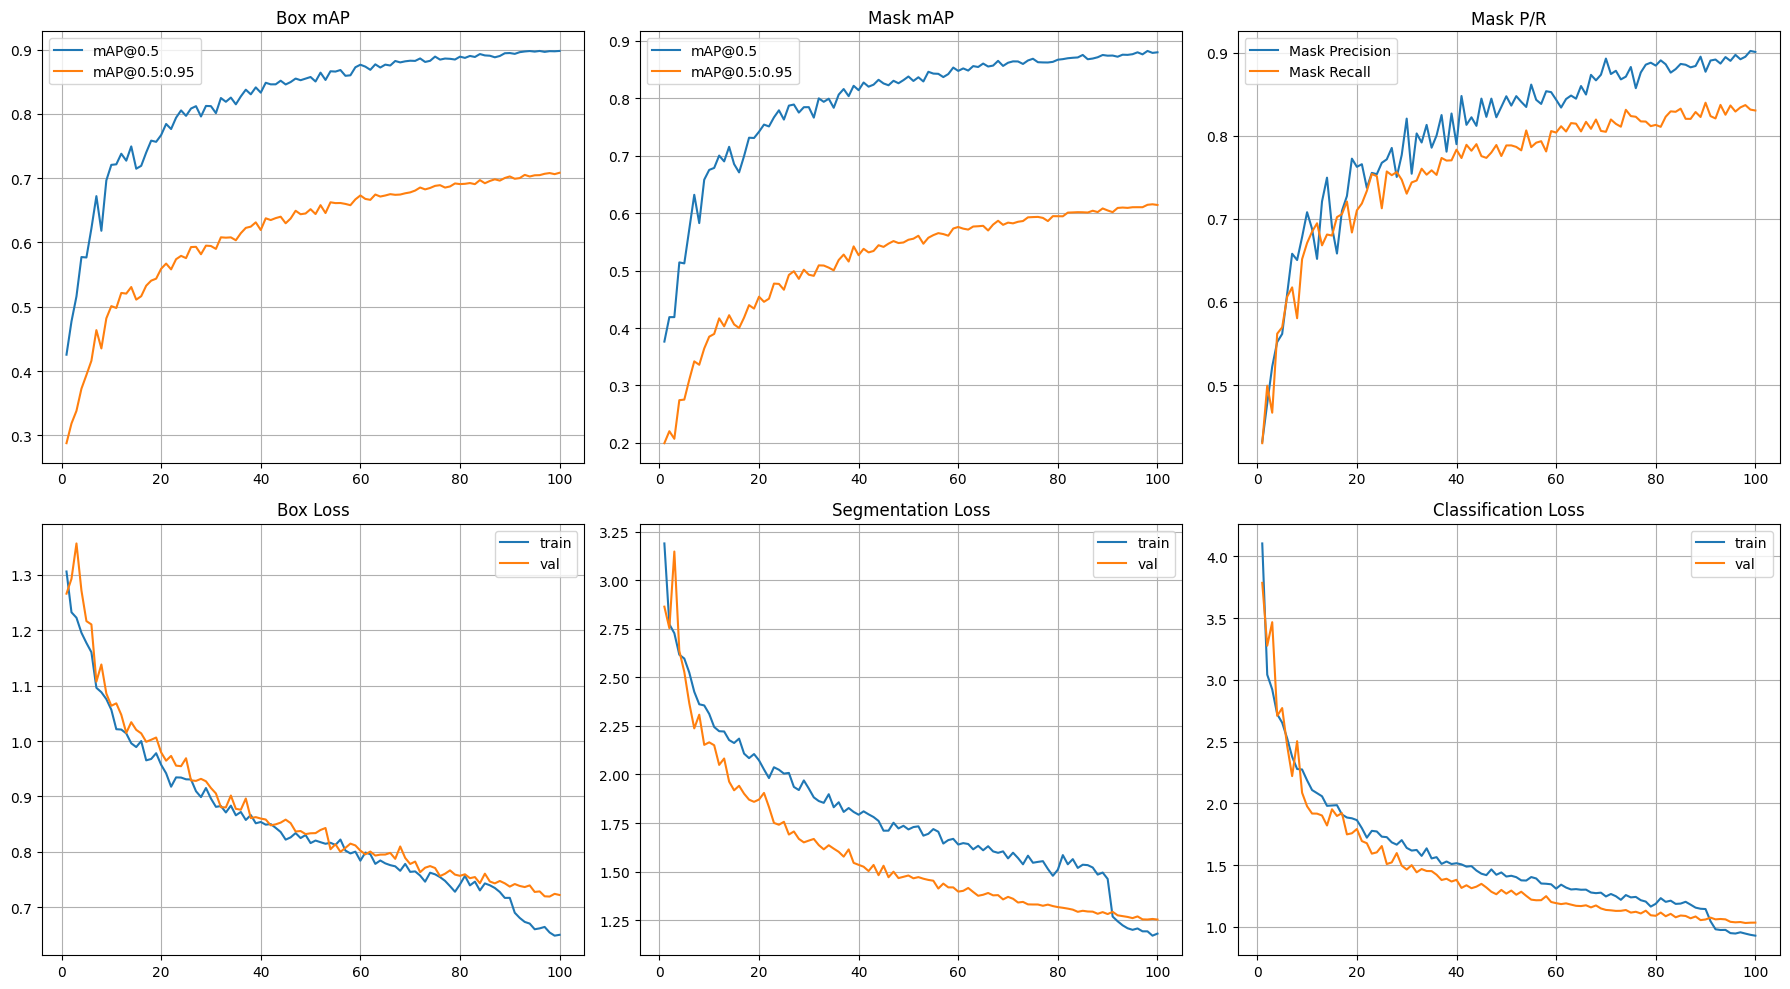

Best epoch by Mask mAP@0.5: 98
  Mask mAP@0.5:     0.8825
  Mask mAP@0.5:.95: 0.6146
✅ Found confusion matrix: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_test_eval/confusion_matrix.png


In [7]:
def copy_if_exists(src, dst_dir, rename=None):
    src = Path(src)
    dst_dir = Path(dst_dir)
    if src.exists():
        dst = dst_dir / (rename or src.name)
        shutil.copy2(src, dst)
        print(f'✅ Saved: {dst}')
        return str(dst)
    print(f'⚠️ Missing artifact: {src}')
    return None

results_csv = run_dir / 'results.csv'
training_curves_path = run_dir / 'training_curves.png'
best_epoch = None
results_df = None

if results_csv.exists():
    results_df = pd.read_csv(results_csv)
    results_df.columns = [c.strip() for c in results_df.columns]
    if 'epoch' not in results_df.columns:
        results_df['epoch'] = np.arange(1, len(results_df) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    def plot_if(cols, ax, title):
        found = False
        for col, label in cols:
            if col in results_df.columns:
                ax.plot(results_df['epoch'], results_df[col], label=label)
                found = True
        ax.set_title(title)
        ax.grid(True)
        if found:
            ax.legend()
        else:
            ax.text(0.5, 0.5, 'metric not found', ha='center', va='center')

    plot_if([('metrics/mAP50(B)', 'mAP@0.5'), ('metrics/mAP50-95(B)', 'mAP@0.5:0.95')], axes[0, 0], 'Box mAP')
    plot_if([('metrics/mAP50(M)', 'mAP@0.5'), ('metrics/mAP50-95(M)', 'mAP@0.5:0.95')], axes[0, 1], 'Mask mAP')
    plot_if([('metrics/precision(M)', 'Mask Precision'), ('metrics/recall(M)', 'Mask Recall')], axes[0, 2], 'Mask P/R')
    plot_if([('train/box_loss', 'train'), ('val/box_loss', 'val')], axes[1, 0], 'Box Loss')
    plot_if([('train/seg_loss', 'train'), ('val/seg_loss', 'val')], axes[1, 1], 'Segmentation Loss')
    plot_if([('train/cls_loss', 'train'), ('val/cls_loss', 'val')], axes[1, 2], 'Classification Loss')

    plt.tight_layout()
    plt.savefig(training_curves_path, dpi=120)
    plt.show()

    metric_col = 'metrics/mAP50(M)' if 'metrics/mAP50(M)' in results_df.columns else None
    if metric_col:
        best_epoch = results_df.loc[results_df[metric_col].idxmax()].to_dict()
        print(f"Best epoch by Mask mAP@0.5: {int(best_epoch['epoch'])}")
        print(f"  Mask mAP@0.5:     {best_epoch.get('metrics/mAP50(M)', float('nan')):.4f}")
        print(f"  Mask mAP@0.5:.95: {best_epoch.get('metrics/mAP50-95(M)', float('nan')):.4f}")
else:
    print(f'⚠️ results.csv not found yet: {results_csv}')

test_eval_dir = Path(getattr(test_results, 'save_dir', DRIVE_RUNS / f'{run_name}_test_eval'))
conf_candidates = [
    test_eval_dir / 'confusion_matrix.png',
    test_eval_dir / 'confusion_matrix_normalized.png',
    run_dir / 'confusion_matrix.png',
]
confusion_matrix_path = None
for candidate in conf_candidates:
    if candidate.exists():
        confusion_matrix_path = candidate
        print(f'✅ Found confusion matrix: {confusion_matrix_path}')
        break
if confusion_matrix_path is None:
    print('⚠️ Confusion matrix image not found. Test eval plots may still be in:', test_eval_dir)

## 7️⃣ Save Final Artifacts + Summary
Copy best weights, last checkpoint, configs, plots, and final metrics into a stable final folder on Drive.

In [8]:
final_dir.mkdir(parents=True, exist_ok=True)

saved_artifacts = {}
for src, rename in [
    (run_dir / 'weights' / 'best.pt', 'best.pt'),
    (run_dir / 'weights' / 'last.pt', 'last.pt'),
    (run_dir / 'results.csv', 'results.csv'),
    (run_dir / 'args.yaml', 'args.yaml'),
    (training_curves_path, 'training_curves.png'),
]:
    saved = copy_if_exists(src, final_dir, rename=rename)
    if saved:
        saved_artifacts[rename] = saved

if confusion_matrix_path is not None:
    saved = copy_if_exists(confusion_matrix_path, final_dir, rename='test_confusion_matrix.png')
    if saved:
        saved_artifacts['test_confusion_matrix.png'] = saved

per_class_maps = {}
for i, name in class_names.items():
    per_class_maps[str(name)] = float(test_results.seg.maps[i]) if i < len(test_results.seg.maps) else None

final_summary = {
    'model': 'yolov8s-seg',
    'run_name': run_name,
    'run_dir': str(run_dir),
    'final_dir': str(final_dir),
    'dataset_yaml': str(DATA_YAML),
    'created_at': datetime.now(timezone.utc).isoformat(),
    'training_meta': training_meta,
    'training_config': train_config,
    'epochs_trained': int(results_df['epoch'].max()) if results_df is not None and 'epoch' in results_df.columns else None,
    'best_epoch_by_mask_mAP50': int(best_epoch['epoch']) if best_epoch is not None and 'epoch' in best_epoch else None,
    'test_box_mAP50': float(test_results.box.map50),
    'test_box_mAP50_95': float(test_results.box.map),
    'test_mask_mAP50': float(test_results.seg.map50),
    'test_mask_mAP50_95': float(test_results.seg.map),
    'test_per_class_seg_maps': per_class_maps,
    'saved_artifacts': saved_artifacts,
    'ready_for_phase7': bool((final_dir / 'best.pt').exists()),
}

summary_path = final_dir / 'training_summary.json'
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(final_summary, f, indent=2, ensure_ascii=False)
saved_artifacts['training_summary.json'] = str(summary_path)

ready = 'YES ✅' if final_summary['ready_for_phase7'] else 'NO ⚠️'
print('╔' + '═' * 70 + '╗')
print('║  Phase 6 — YOLOv8s-seg Training Complete'.ljust(71) + '║')
print('╠' + '═' * 70 + '╣')
print(f'║  Run: {run_name}'.ljust(71) + '║')
print(f'║  Best weights: {"saved" if (final_dir / "best.pt").exists() else "missing"}'.ljust(71) + '║')
print(f'║  Box mAP@0.5:       {test_results.box.map50:.4f}'.ljust(71) + '║')
print(f'║  Box mAP@0.5:0.95:  {test_results.box.map:.4f}'.ljust(71) + '║')
print(f'║  Mask mAP@0.5:      {test_results.seg.map50:.4f}'.ljust(71) + '║')
print(f'║  Mask mAP@0.5:0.95: {test_results.seg.map:.4f}'.ljust(71) + '║')
print(f'║  Ready for Phase 7: {ready}'.ljust(71) + '║')
print('╚' + '═' * 70 + '╝')
print(f'💾 Final summary: {summary_path}')
print('\nSaved artifacts:')
for key, value in saved_artifacts.items():
    print(f'  {key}: {value}')

✅ Saved: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final/best.pt
✅ Saved: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final/last.pt
✅ Saved: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final/results.csv
✅ Saved: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final/args.yaml
✅ Saved: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final/training_curves.png
✅ Saved: /content/drive/MyDrive/ai builders/runs/solar_yolov8s_v1_final/test_confusion_matrix.png
╔══════════════════════════════════════════════════════════════════════╗
║  Phase 6 — YOLOv8s-seg Training Complete                             ║
╠══════════════════════════════════════════════════════════════════════╣
║  Run: solar_yolov8s_v1                                               ║
║  Best weights: saved                                                 ║
║  Box mAP@0.5:       0.8924                                           ║
║  Box mAP@0.5:0.95:  0.7006                  

## 8️⃣ Notes For Phase 7
Use `best.pt` from the final folder for error analysis, severity calculation, and urgency rule experiments.